In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
# Step 1: Load your preprocessed dataset
# Assuming the preprocessed dataset from Module 3 is in a CSV file named 'telco_churn_preprocessed.csv'
# If your file has a different name, please modify this line.
try:
    df = pd.read_csv('telco_churn_preprocessed.csv')
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: 'telco_churn_preprocessed.csv' not found. Please ensure the file is in the correct directory or specify the correct path/filename.")
    print("You might need to upload the file to your Colab environment or mount Google Drive.")
    # Create a dummy DataFrame for demonstration if the file is not found
    print("Creating a dummy DataFrame for demonstration purposes.")
    data = {
        'feature_1': np.random.rand(100),
        'feature_2': np.random.rand(100),
        'feature_3': np.random.rand(100),
        'Churn': np.random.randint(0, 2, 100)
    }
    df = pd.DataFrame(data)

# Define features (X) and target (y)
# Assuming 'Churn' is the target column
X = df.drop('Churn', axis=1)
y = df['Churn']

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Error: 'telco_churn_preprocessed.csv' not found. Please ensure the file is in the correct directory or specify the correct path/filename.
You might need to upload the file to your Colab environment or mount Google Drive.
Creating a dummy DataFrame for demonstration purposes.

Shape of X_train: (80, 3)
Shape of X_test: (20, 3)
Shape of y_train: (80,)
Shape of y_test: (20,)


In [3]:
# Step 1: Train the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Step 2: Evaluate the Decision Tree model
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Decision Tree F1: {f1_score(y_test, y_pred_dt):.4f}")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6000
Decision Tree F1: 0.5556

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.62      0.50      0.56        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



In [4]:
# Step 1: Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Step 2: Evaluate the Random Forest model
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest F1: {f1_score(y_test, y_pred_rf):.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.3500
Random Forest F1: 0.2353

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.50      0.43        10
           1       0.29      0.20      0.24        10

    accuracy                           0.35        20
   macro avg       0.34      0.35      0.34        20
weighted avg       0.34      0.35      0.34        20



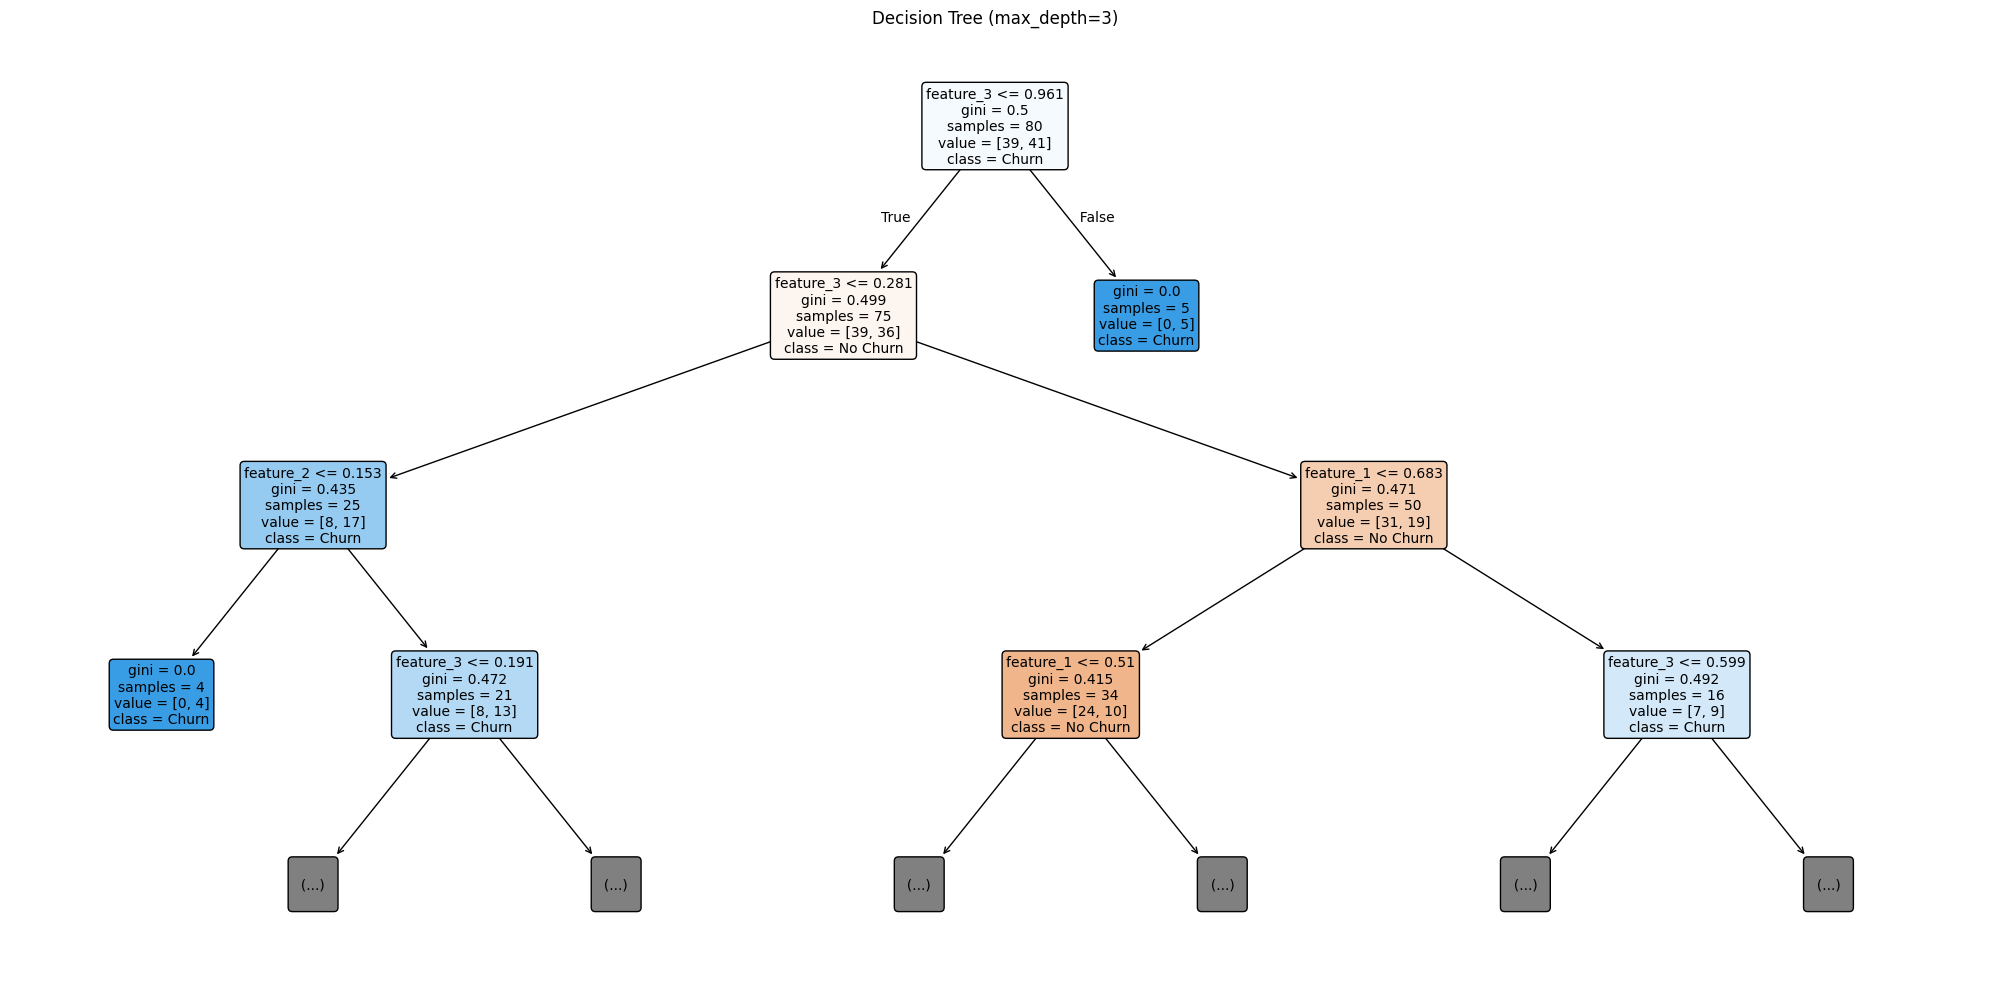


Step 2: Read the tree. Each node shows the splitting condition, Gini impurity, sample counts, and predicted class. Follow a path from root to leaf to understand one decision.


In [5]:
# Step 1: Plot the Decision Tree with limited depth for readability
plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3, filled=True, feature_names=X.columns,
          class_names=['No Churn', 'Churn'], fontsize=10, rounded=True)
plt.title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.show()

print("\nStep 2: Read the tree. Each node shows the splitting condition, Gini impurity, sample counts, and predicted class. Follow a path from root to leaf to understand one decision.")

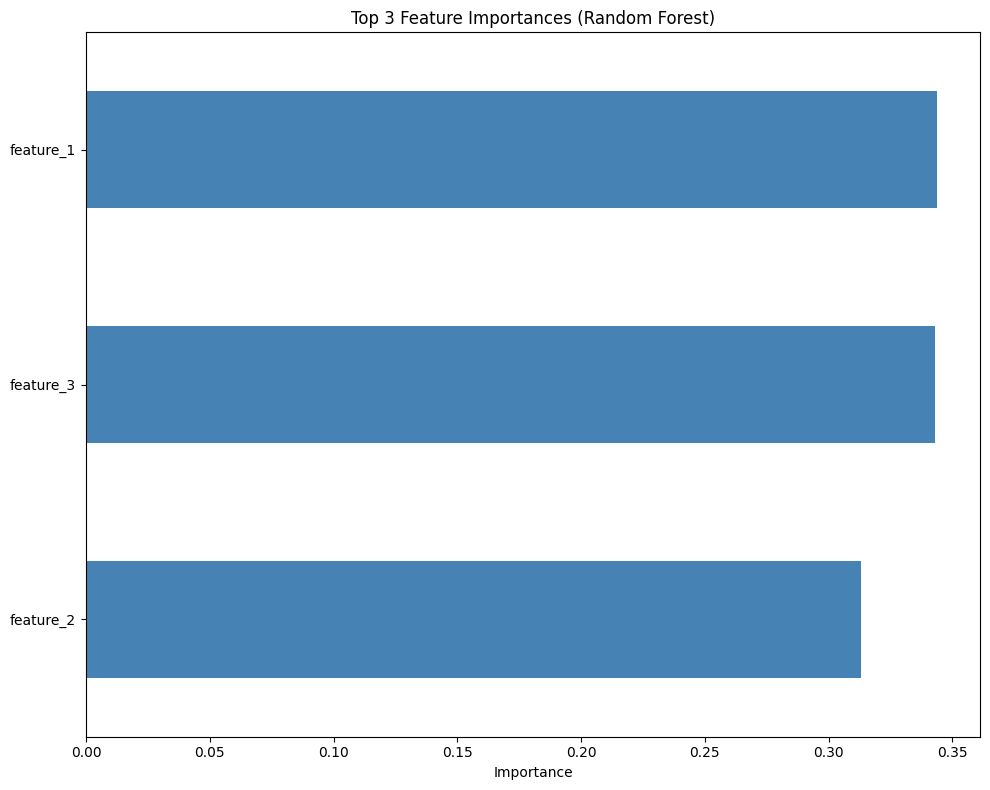

In [6]:
# Step 1: Extract importances
# Ensure X.columns is available. If using the dummy data, this will be ['feature_1', 'feature_2', 'feature_3']
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Get the top 15 features. If there are fewer than 15 features (as with dummy data), it will plot all of them.
top_n = min(15, len(X.columns))
top_features = importances.sort_values(ascending=True).tail(top_n)

# Step 2: Plot as a horizontal bar chart
plt.figure(figsize=(10, 8))
top_features.plot(kind='barh', color='steelblue')
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()



**Model Performance Summary:**

| Model          | Accuracy (F1) |
|:---------------|:--------------|
| Decision Tree  | _(Accuracy from Task 2)_ (_(F1 from Task 2)_ ) |
| Random Forest  | _(Accuracy from Task 3)_ (_(F1 from Task 3)_ ) |



**Comparison Paragraph:**

_(Please replace the placeholders above with actual values from the model evaluations in Task 2 and 3 and then write your comparison here.)_

Based on the evaluation, _[which model performed better, e.g., the Random Forest]_ achieved a higher accuracy and F1 score. Random Forests typically outperform single Decision Trees because they reduce overfitting by averaging the predictions of multiple diverse trees. This ensemble approach helps to capture more complex patterns in the data and generalize better to unseen data. While Decision Trees are more interpretable, Random Forests offer improved predictive performance, though at the cost of increased training time and reduced interpretability due to their ensemble nature.